# World Happiness Analysis (2015-2019): Predicting Global Happiness Using Machine Learning

## Project Overview

The purpose of this data science project is to analyze the World Happiness Report dataset from 2015 to 2019 and identify the key factors that influence happiness levels across countries.

The project applies Exploratory Data Analysis (EDA), data preprocessing techniques, and machine learning regression models to predict the Happiness Score of different countries based on economic, social, and health-related factors.

The analysis includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Outlier detection
- Feature relationships analysis
- Linear Regression
- Polynomial Regression
- Ridge Regression
- Hyperparameter tuning using GridSearchCV

The final objective is to compare different machine learning approaches and determine which model provides the best prediction performance.

Dataset Source:
World Happiness Report Dataset - Kaggle
https://www.kaggle.com/datasets

## Import Required Libraries

The following Python libraries are imported for data manipulation, visualization, preprocessing, machine learning modeling, and model evaluation.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing and models
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Model evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

The World Happiness Report datasets from 2015 to 2019 are loaded. Each file represents happiness indicators collected for countries around the world during a specific year.

A Year column is added to each dataset to allow time-based analysis.

In [4]:
# Define folder path
path = r"C:\Users\Fjgon\OneDrive\Documentos\Personal\SEU\DATA ANALISYS\Personal Project"


# Load datasets

df_2015 = pd.read_csv(path + r"\2015.csv")
df_2016 = pd.read_csv(path + r"\2016.csv")
df_2017 = pd.read_csv(path + r"\2017.csv")
df_2018 = pd.read_csv(path + r"\2018.csv")
df_2019 = pd.read_csv(path + r"\2019.csv")


# Add year column

df_2015["Year"] = 2015
df_2016["Year"] = 2016
df_2017["Year"] = 2017
df_2018["Year"] = 2018
df_2019["Year"] = 2019


# Check one dataset

df_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


## Initial Dataset Inspection

Before combining the datasets, each file is inspected to understand its structure, number of records, and available features.

In [5]:
print("2015:", df_2015.shape)
print("2016:", df_2016.shape)
print("2017:", df_2017.shape)
print("2018:", df_2018.shape)
print("2019:", df_2019.shape)

2015: (158, 13)
2016: (157, 14)
2017: (155, 13)
2018: (156, 10)
2019: (156, 10)


In [7]:
# Display information for each dataset before combining

datasets = {
    "2015": df_2015,
    "2016": df_2016,
    "2017": df_2017,
    "2018": df_2018,
    "2019": df_2019
}

for year, data in datasets.items():
    print("\n==============================")
    print(f"Dataset Year: {year}")
    print("==============================")
    data.info()


Dataset Year: 2015
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
 12  Year                          

## Data Standardization

Since the World Happiness Report datasets come from different years, some columns have different names while representing the same information.

Before merging the datasets, column names are standardized to create a consistent structure across all years.

In [8]:
# Standardize column names for each dataset


df_2015 = df_2015.rename(columns={
    'Country': 'Country',
    'Region': 'Region',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Happiness Score',
    'Economy (GDP per Capita)': 'GDP',
    'Family': 'Social Support',
    'Health (Life Expectancy)': 'Health',
    'Freedom': 'Freedom',
    'Trust (Government Corruption)': 'Trust',
    'Generosity': 'Generosity'
})


df_2016 = df_2016.rename(columns={
    'Country': 'Country',
    'Region': 'Region',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Happiness Score',
    'Economy (GDP per Capita)': 'GDP',
    'Family': 'Social Support',
    'Health (Life Expectancy)': 'Health',
    'Freedom': 'Freedom',
    'Trust (Government Corruption)': 'Trust',
    'Generosity': 'Generosity'
})


df_2017 = df_2017.rename(columns={
    'Country': 'Country',
    'Happiness.Rank': 'Rank',
    'Happiness.Score': 'Happiness Score',
    'Economy..GDP.per.Capita.': 'GDP',
    'Family': 'Social Support',
    'Health..Life.Expectancy.': 'Health',
    'Freedom': 'Freedom',
    'Trust..Government.Corruption.': 'Trust',
    'Generosity': 'Generosity'
})


df_2018 = df_2018.rename(columns={
    'Country or region': 'Country',
    'Overall rank': 'Rank',
    'Score': 'Happiness Score',
    'GDP per capita': 'GDP',
    'Social support': 'Social Support',
    'Healthy life expectancy': 'Health',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust',
    'Generosity': 'Generosity'
})


df_2019 = df_2019.rename(columns={
    'Country or region': 'Country',
    'Overall rank': 'Rank',
    'Score': 'Happiness Score',
    'GDP per capita': 'GDP',
    'Social support': 'Social Support',
    'Healthy life expectancy': 'Health',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust',
    'Generosity': 'Generosity'
})

## Feature Selection Before Combining Data

Only the variables available across all years are selected. This ensures consistency and avoids missing columns caused by differences between yearly reports.

In [9]:
# Select common columns

columns = [
    'Country',
    'Rank',
    'Happiness Score',
    'GDP',
    'Social Support',
    'Health',
    'Freedom',
    'Trust',
    'Generosity',
    'Year'
]


df_2015 = df_2015[columns]
df_2016 = df_2016[columns]
df_2017 = df_2017[columns]
df_2018 = df_2018[columns]
df_2019 = df_2019[columns]

## Combining Datasets

After standardizing the structure, all yearly datasets are combined into one final dataframe containing happiness data from 2015 to 2019.

In [10]:
# Combine all years into one dataframe

df = pd.concat(
    [
        df_2015,
        df_2016,
        df_2017,
        df_2018,
        df_2019
    ],
    ignore_index=True
)


# Display combined dataset

df.head()

,Country,Rank,Happiness Score,GDP,Social Support,Health,Freedom,Trust,Generosity,Year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [11]:
df.shape

(782, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    object 
 1   Rank             782 non-null    int64  
 2   Happiness Score  782 non-null    float64
 3   GDP              782 non-null    float64
 4   Social Support   782 non-null    float64
 5   Health           782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Trust            781 non-null    float64
 8   Generosity       782 non-null    float64
 9   Year             782 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 61.2+ KB


## Data Cleaning and Preprocessing

Before performing Exploratory Data Analysis and building machine learning models, the dataset is reviewed to identify possible data quality issues.

The cleaning process includes:

- Checking missing values
- Identifying duplicate records
- Reviewing data types
- Detecting possible inconsistencies

Proper preprocessing ensures that the dataset is reliable and suitable for predictive modeling.

In [13]:
# Check missing values in the combined dataset

df.isnull().sum()

Country            0
Rank               0
Happiness Score    0
GDP                0
Social Support     0
Health             0
Freedom            0
Trust              1
Generosity         0
Year               0
dtype: int64

In [14]:
# Calculate missing values percentage

missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage (%)
Country,0,0.000000
Rank,0,0.000000
Happiness Score,0,0.000000
GDP,0,0.000000
Social Support,0,0.000000
Health,0,0.000000
Freedom,0,0.000000
Trust,1,0.127877
Generosity,0,0.000000
Year,0,0.000000


### Handling Missing Values

Missing numerical values are replaced using the median value of each column.

The median was selected because it is less sensitive to extreme values and helps preserve the original distribution of the data.

In [16]:
# Replace missing numerical values with median

numeric_columns = df.select_dtypes(
    include=['float64', 'int64']
).columns


for column in numeric_columns:
    df[column].fillna(
        df[column].median(),
        inplace=True
    )


# Verify missing values again

df.isnull().sum()

Country            0
Rank               0
Happiness Score    0
GDP                0
Social Support     0
Health             0
Freedom            0
Trust              0
Generosity         0
Year               0
dtype: int64

### Duplicate Records Analysis

Duplicate observations are checked to avoid repeated information that could negatively affect the statistical analysis and machine learning models.

In [18]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [19]:
# Remove duplicates if necessary

df = df.drop_duplicates()

df.shape

(782, 10)

### Data Types Verification

Data types are reviewed to confirm that numerical variables are correctly formatted before visualization and machine learning modeling.

In [20]:
# Check final dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    object 
 1   Rank             782 non-null    int64  
 2   Happiness Score  782 non-null    float64
 3   GDP              782 non-null    float64
 4   Social Support   782 non-null    float64
 5   Health           782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Trust            782 non-null    float64
 8   Generosity       782 non-null    float64
 9   Year             782 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 61.2+ KB


## Descriptive Statistics

Summary statistics are generated to understand the central tendency, variability, and range of numerical features.

In [22]:
df.describe()

,Rank,Happiness Score,GDP,Social Support,Health,Freedom,Trust,Generosity,Year
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,78.698210,5.379018,0.916047,1.078392,0.612416,0.411091,0.125392,0.218576,2016.993606
std,45.182384,1.127456,0.407340,0.329548,0.248309,0.152880,0.105756,0.122321,1.417364
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,40.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.054250,0.130000,2016.000000
50%,79.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.091000,0.201982,2017.000000
75%,118.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.155861,0.278832,2018.000000
max,158.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,2019.000000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand the World Happiness dataset and identify important patterns among countries and years.

This section explores:

- Distribution of happiness scores
- Global happiness trends over time
- Highest and lowest happiness countries
- Outlier detection
- Relationships between socioeconomic factors and happiness
- Feature correlations

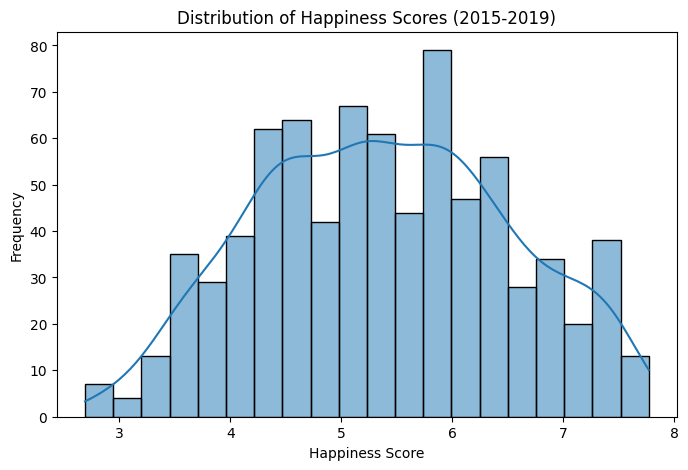

In [23]:
# Distribution of Happiness Score

plt.figure(figsize=(8,5))

sns.histplot(
    df['Happiness Score'],
    bins=20,
    kde=True
)

plt.title("Distribution of Happiness Scores (2015-2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")

plt.show()

### Happiness Score Distribution Interpretation

The distribution shows how happiness scores vary across countries from 2015 to 2019.

Most countries are concentrated around the middle happiness levels, while fewer countries appear at extremely high or low scores.

Understanding this distribution helps identify global happiness patterns and potential differences among countries.

In [24]:
# Average happiness score by year

yearly_happiness = df.groupby('Year')['Happiness Score'].mean()

yearly_happiness

Year
2015    5.375734
2016    5.382185
2017    5.354019
2018    5.375917
2019    5.407096
Name: Happiness Score, dtype: float64

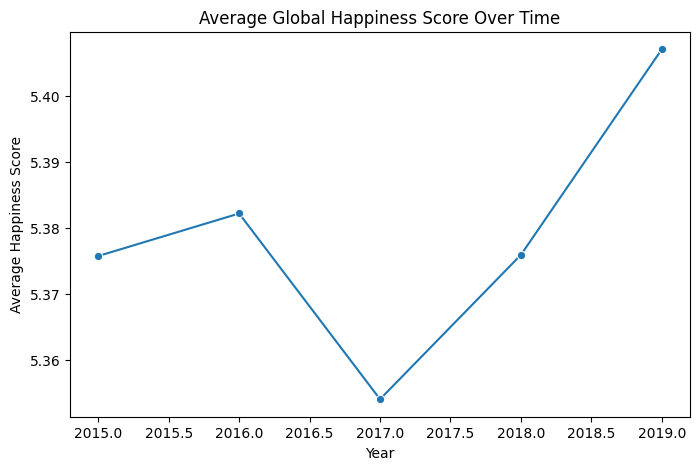

In [25]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=yearly_happiness.index,
    y=yearly_happiness.values,
    marker='o'
)

plt.title("Average Global Happiness Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

### Global Happiness Trend Interpretation

The line chart displays changes in the average Happiness Score between 2015 and 2019.

This analysis helps determine whether global happiness levels increased, decreased, or remained stable over the observed period.

In [26]:
# Top 10 happiest countries based on average score

top_countries = (
    df.groupby('Country')['Happiness Score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: Happiness Score, dtype: float64

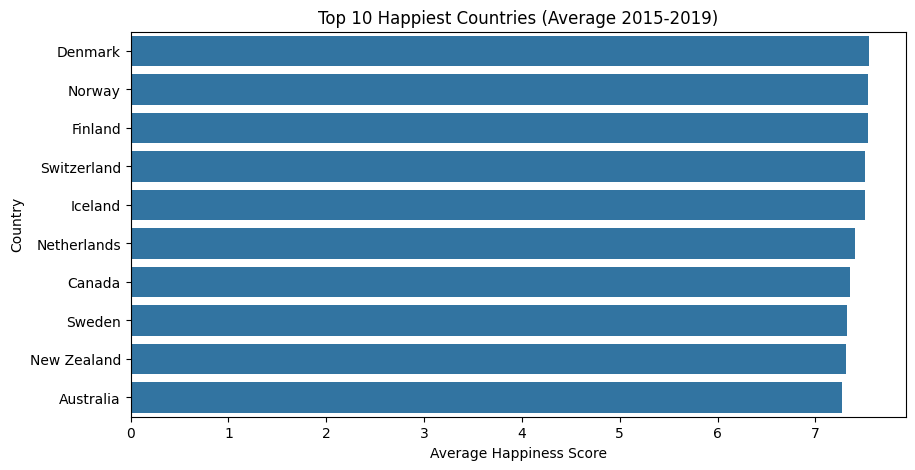

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Happiest Countries (Average 2015-2019)")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")

plt.show()

### Happiest Countries Interpretation

The ranking shows the countries with the highest average Happiness Scores during the analyzed period.

Countries at the top generally combine strong economic conditions, social support, health, and personal freedom.

## Outlier Analysis

Boxplots are used to identify possible extreme values in numerical variables.

Outliers are important because they may influence statistical analysis and machine learning model performance.

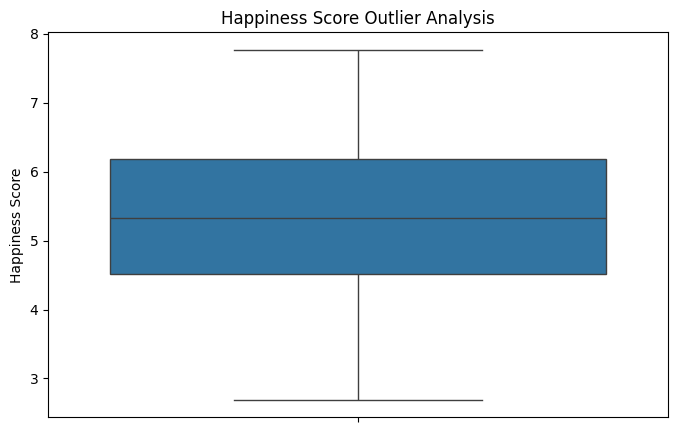

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Happiness Score']
)

plt.title("Happiness Score Outlier Analysis")

plt.show()

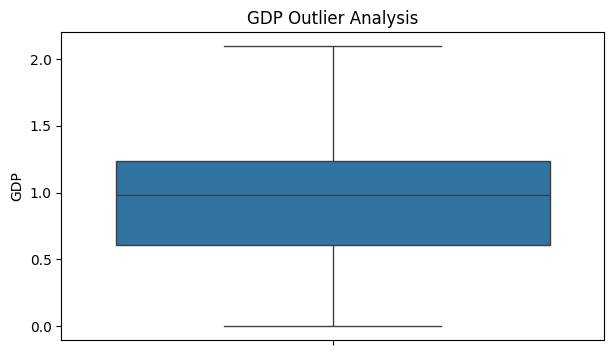

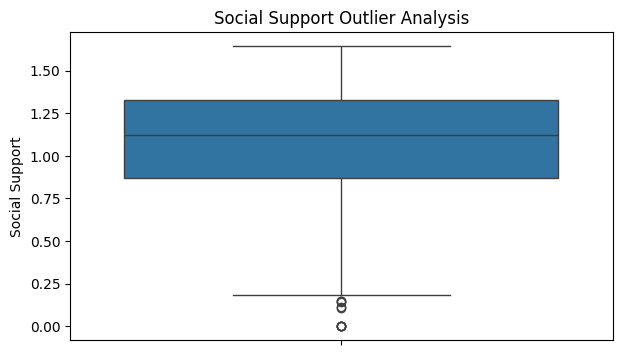

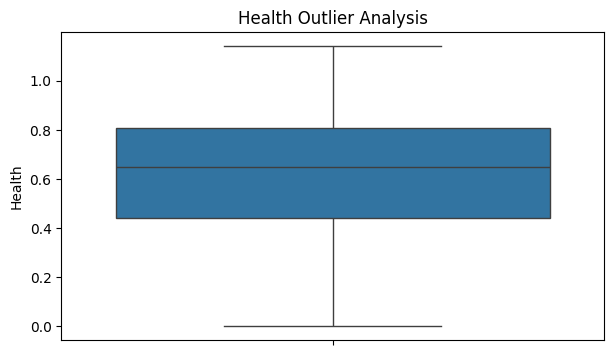

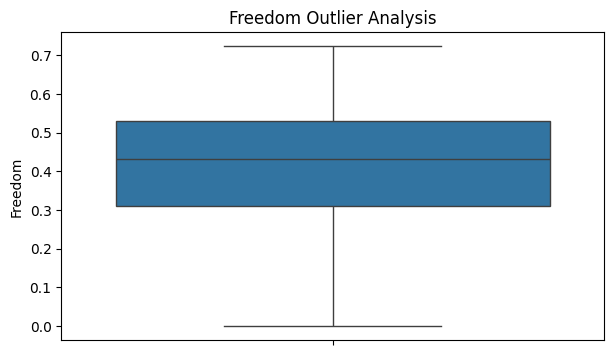

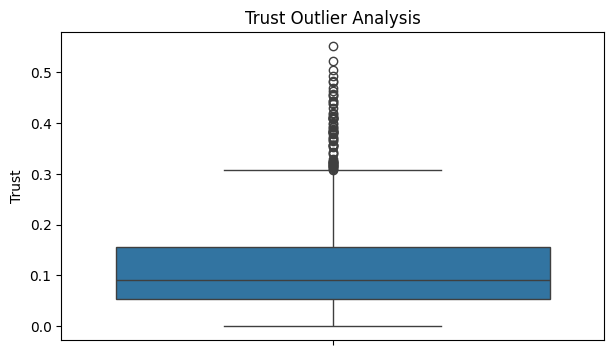

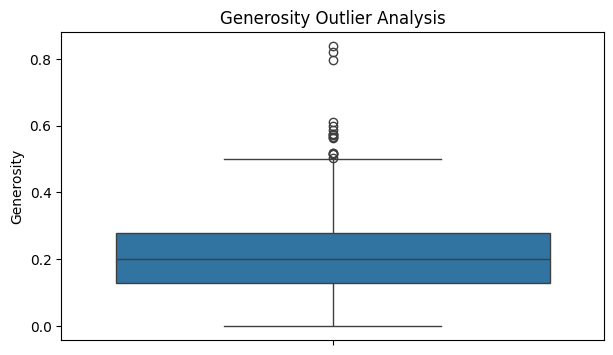

In [30]:
numeric_features = [
    'GDP',
    'Social Support',
    'Health',
    'Freedom',
    'Trust',
    'Generosity'
]


for feature in numeric_features:

    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        y=df[feature]
    )
    
    plt.title(feature + " Outlier Analysis")
    
    plt.show()

### Outlier Interpretation

The boxplots reveal potential extreme values across happiness indicators.

These values represent countries with unusually high or low socioeconomic characteristics.

Since these observations represent real differences among countries, they are kept in the dataset instead of being removed.

## Correlation Analysis

Correlation analysis is performed to understand the strength and direction of relationships between numerical variables.

This helps identify which factors have the strongest association with Happiness Score and supports feature selection for machine learning models.

In [31]:
# Calculate correlation matrix

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Rank,Happiness Score,GDP,Social Support,Health,Freedom,Trust,Generosity,Year
Rank,1.000000,-0.992066,-0.794791,-0.644842,-0.743655,-0.537942,-0.371810,-0.117713,-0.007768
Happiness Score,-0.992066,1.000000,0.789284,0.648799,0.742456,0.551258,0.397484,0.137578,0.007065
GDP,-0.794791,0.789284,1.000000,0.585966,0.784338,0.340511,0.303427,-0.014560,0.019768
Social Support,-0.644842,0.648799,0.585966,1.000000,0.572650,0.420361,0.126707,-0.037262,0.367431
Health,-0.743655,0.742456,0.784338,0.572650,1.000000,0.340745,0.250390,0.010638,0.130302
Freedom,-0.537942,0.551258,0.340511,0.420361,0.340745,1.000000,0.459705,0.290706,0.010353
Trust,-0.371810,0.397484,0.303427,0.126707,0.250390,0.459705,1.000000,0.318995,-0.122513
Generosity,-0.117713,0.137578,-0.014560,-0.037262,0.010638,0.290706,0.318995,1.000000,-0.192587
Year,-0.007768,0.007065,0.019768,0.367431,0.130302,0.010353,-0.122513,-0.192587,1.000000


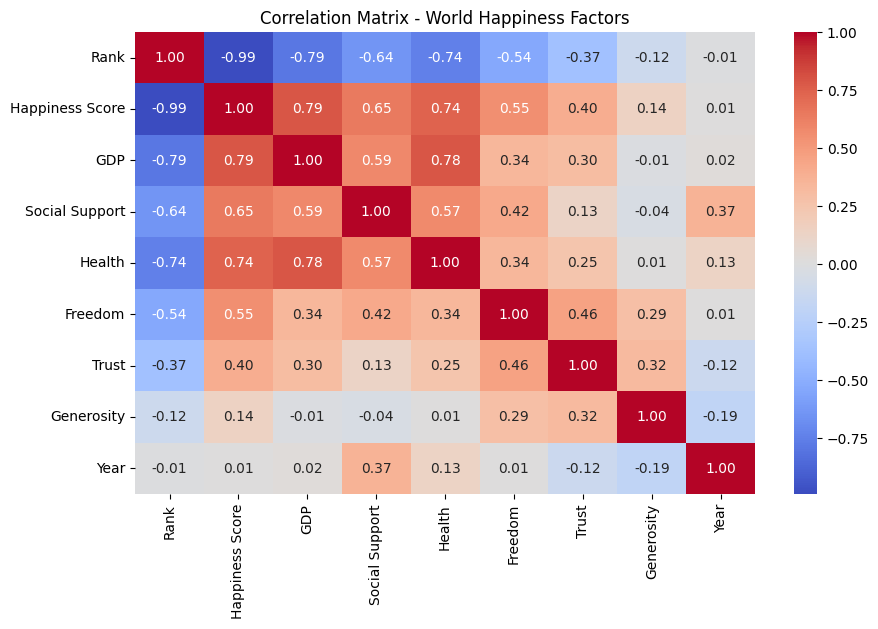

In [32]:
# Correlation heatmap visualization

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix - World Happiness Factors")

plt.show()

### Correlation Matrix Interpretation

The correlation matrix shows the relationship between Happiness Score and the main socioeconomic indicators.

Variables with stronger positive correlations indicate that increases in those factors are generally associated with higher happiness levels.

GDP, Social Support, and Health are expected to have some of the strongest relationships with Happiness Score, suggesting that economic development, quality of life, and social connections play important roles in global happiness.

In [33]:
# Display correlations with Happiness Score

happiness_correlation = (
    correlation_matrix['Happiness Score']
    .sort_values(ascending=False)
)

happiness_correlation

Happiness Score    1.000000
GDP                0.789284
Health             0.742456
Social Support     0.648799
Freedom            0.551258
Trust              0.397484
Generosity         0.137578
Year               0.007065
Rank              -0.992066
Name: Happiness Score, dtype: float64

### Feature Importance Based on Correlation

The correlation ranking helps identify the variables most related to Happiness Score.

Features with stronger correlations are expected to provide better predictive power when developing regression models.

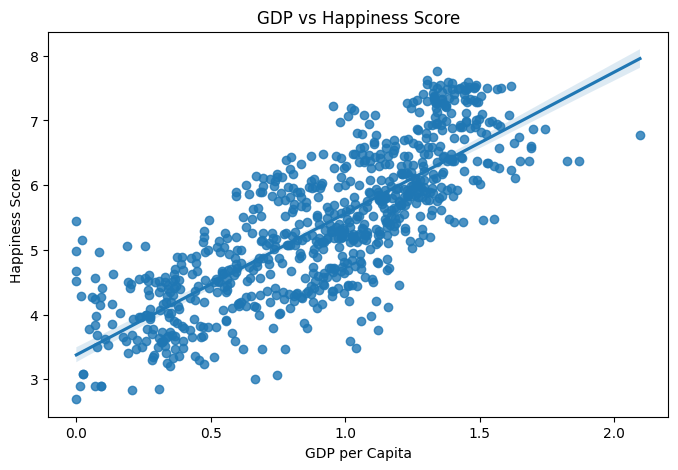

In [35]:
# Relationship between GDP and Happiness Score

plt.figure(figsize=(8,5))

sns.regplot(
    x='GDP',
    y='Happiness Score',
    data=df
)

plt.title("GDP vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

### GDP Relationship Interpretation

The scatterplot shows a positive relationship between GDP per capita and Happiness Score.

Countries with higher economic indicators generally report higher happiness levels, suggesting GDP is an important predictor variable.

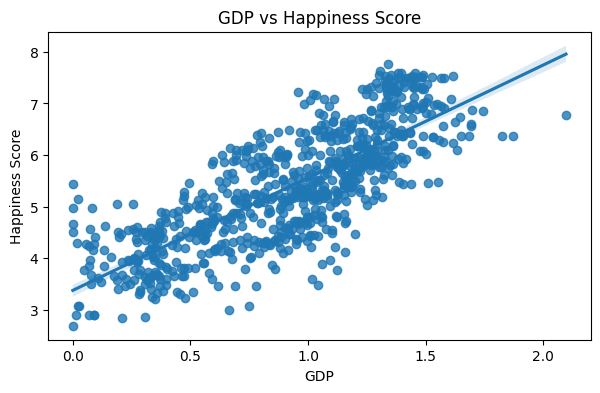

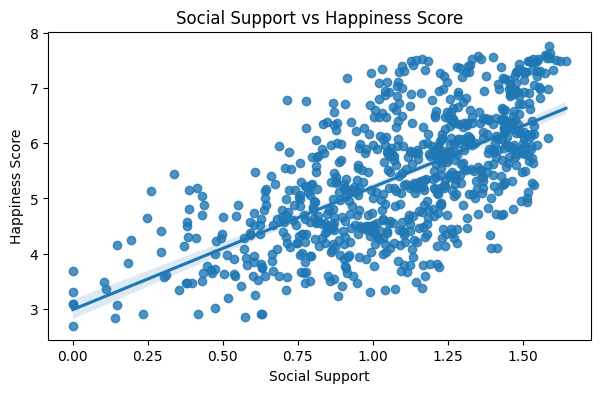

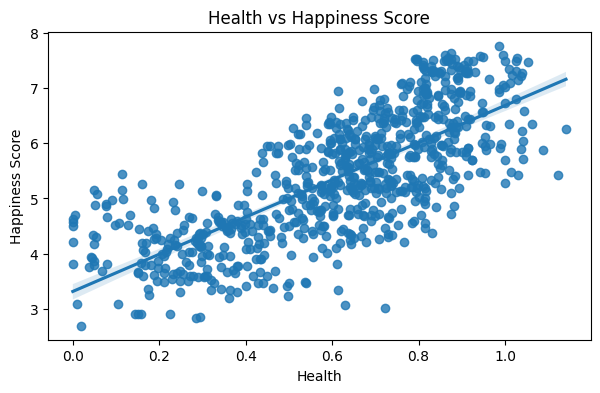

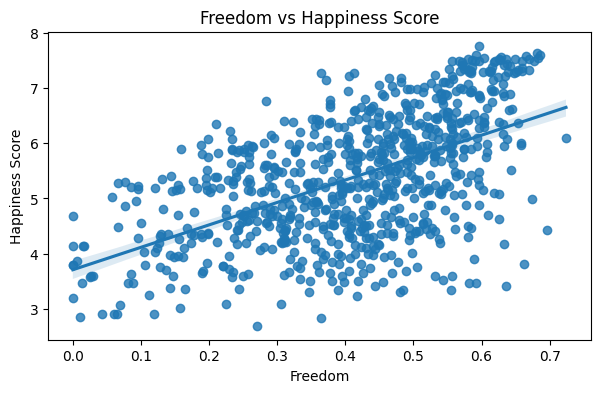

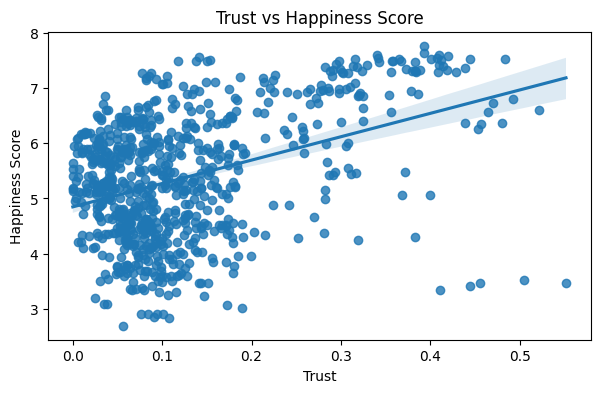

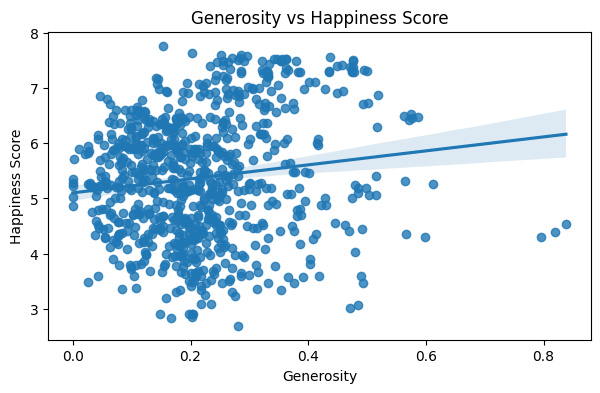

In [36]:
# Analyze relationship between all main predictors and Happiness Score

features = [
    'GDP',
    'Social Support',
    'Health',
    'Freedom',
    'Trust',
    'Generosity'
]


for feature in features:
    
    plt.figure(figsize=(7,4))
    
    sns.regplot(
        x=df[feature],
        y=df['Happiness Score']
    )
    
    plt.title(feature + " vs Happiness Score")
    plt.xlabel(feature)
    plt.ylabel("Happiness Score")
    
    plt.show()

## Machine Learning Modeling

This section develops and compares regression models to predict the Happiness Score.

The target variable is Happiness Score, and the predictor variables include socioeconomic and well-being indicators such as GDP, Social Support, Health, Freedom, Trust, and Generosity.

The models are evaluated using three performance metrics:

- RMSE: Measures the average prediction error with higher penalty for larger errors.
- MAE: Measures the average absolute prediction error.
- R²: Measures how much variance in Happiness Score is explained by the model.

In [38]:
# Define target variable

y = df['Happiness Score']


# Define predictor variables

features = [
    'GDP',
    'Social Support',
    'Health',
    'Freedom',
    'Trust',
    'Generosity'
]

X = df[features]

## Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to build the models, while the testing set is used to evaluate how well the models perform on unseen data.

In [39]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (625, 6)
Testing features: (157, 6)
Training target: (625,)
Testing target: (157,)


## Model Evaluation Function

A reusable function is created to evaluate each regression model using RMSE, MAE, and R².

In [40]:
# Create function to evaluate model performance

def evaluate_model(model_name, approach, y_true, y_pred):
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Approach': approach,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    }

In [41]:
# List to store model results

model_results = []

## Linear Regression - Single Variable Approach

The first model uses GDP as the only predictor variable because it showed a strong relationship with Happiness Score during the correlation analysis.

In [42]:
# Define single-variable feature

X_single = df[['GDP']]
y_single = df['Happiness Score']


# Split single-variable data

X_single_train, X_single_test, y_single_train, y_single_test = train_test_split(
    X_single,
    y_single,
    test_size=0.2,
    random_state=42
)


# Create and train Linear Regression model

linear_single = LinearRegression()

linear_single.fit(
    X_single_train,
    y_single_train
)


# Make predictions

y_pred_linear_single = linear_single.predict(X_single_test)


# Evaluate model

model_results.append(
    evaluate_model(
        'Linear Regression',
        'Single Variable: GDP',
        y_single_test,
        y_pred_linear_single
    )
)


model_results[-1]

{'Model': 'Linear Regression',
 'Approach': 'Single Variable: GDP',
 'RMSE': np.float64(0.6809288476159961),
 'MAE': 0.5487356822075065,
 'R2 Score': 0.6188158513743292}

## Linear Regression - Multiple Variable Approach

The multiple variable Linear Regression model uses all selected predictors to estimate Happiness Score.

This approach allows the model to consider several socioeconomic and well-being indicators at the same time.

In [43]:
# Create and train multiple-variable Linear Regression model

linear_multi = LinearRegression()

linear_multi.fit(
    X_train,
    y_train
)


# Make predictions

y_pred_linear_multi = linear_multi.predict(X_test)


# Evaluate model

model_results.append(
    evaluate_model(
        'Linear Regression',
        'Multiple Variables',
        y_test,
        y_pred_linear_multi
    )
)


model_results[-1]

{'Model': 'Linear Regression',
 'Approach': 'Multiple Variables',
 'RMSE': np.float64(0.5739856433559841),
 'MAE': 0.44145143408445314,
 'R2 Score': 0.7291471403826325}

In [44]:
# Display current model comparison results

pd.DataFrame(model_results)

,Model,Approach,RMSE,MAE,R2 Score
0,Linear Regression,Single Variable: GDP,0.680929,0.548736,0.618816
1,Linear Regression,Multiple Variables,0.573986,0.441451,0.729147


## Polynomial Regression Models

Polynomial Regression is used to capture possible non-linear relationships between the predictors and Happiness Score.

Unlike simple Linear Regression, Polynomial Regression creates additional polynomial features that allow the model to identify more complex patterns.

Both single-variable and multiple-variable approaches are evaluated and compared.

### Polynomial Regression - Single Variable Approach

GDP is used as the single predictor variable to evaluate whether a non-linear relationship improves prediction accuracy compared with a simple linear model.

In [45]:
# Create Polynomial Regression pipeline (single variable)

poly_single_model = Pipeline([
    ('Polynomial Features', PolynomialFeatures(degree=2)),
    ('Linear Regression', LinearRegression())
])


# Train model

poly_single_model.fit(
    X_single_train,
    y_single_train
)


# Predict values

y_pred_poly_single = poly_single_model.predict(
    X_single_test
)


# Evaluate model

model_results.append(
    evaluate_model(
        'Polynomial Regression',
        'Single Variable: GDP',
        y_single_test,
        y_pred_poly_single
    )
)


model_results[-1]

{'Model': 'Polynomial Regression',
 'Approach': 'Single Variable: GDP',
 'RMSE': np.float64(0.6872928064606693),
 'MAE': 0.5547625283478119,
 'R2 Score': 0.6116574641502145}

### Polynomial Regression - Multiple Variable Approach

The multiple-variable Polynomial Regression model transforms all selected predictors into polynomial features.

This allows the model to capture more complex interactions between economic, health, and social factors.

In [46]:
# Create Polynomial Regression pipeline (multiple variables)

poly_multi_model = Pipeline([
    ('Polynomial Features', PolynomialFeatures(degree=2)),
    ('Linear Regression', LinearRegression())
])


# Train model

poly_multi_model.fit(
    X_train,
    y_train
)


# Predict values

y_pred_poly_multi = poly_multi_model.predict(
    X_test
)


# Evaluate model

model_results.append(
    evaluate_model(
        'Polynomial Regression',
        'Multiple Variables',
        y_test,
        y_pred_poly_multi
    )
)


model_results[-1]

{'Model': 'Polynomial Regression',
 'Approach': 'Multiple Variables',
 'RMSE': np.float64(0.5652381203055713),
 'MAE': 0.45182597357517806,
 'R2 Score': 0.7373398110363889}

In [47]:
# Display model comparison table

results_df = pd.DataFrame(model_results)

results_df

,Model,Approach,RMSE,MAE,R2 Score
0,Linear Regression,Single Variable: GDP,0.680929,0.548736,0.618816
1,Linear Regression,Multiple Variables,0.573986,0.441451,0.729147
2,Polynomial Regression,Single Variable: GDP,0.687293,0.554763,0.611657
3,Polynomial Regression,Multiple Variables,0.565238,0.451826,0.737340


### Polynomial Regression Results Interpretation

Polynomial Regression results are compared against Linear Regression models.

If the Polynomial model achieves a lower RMSE and MAE with a higher R² score, this indicates that adding non-linear relationships improved predictive performance.

However, model complexity must also be considered because highly complex models can increase the risk of overfitting.

## Ridge Regression Model

Ridge Regression is an extension of Linear Regression that applies L2 regularization to reduce model complexity and prevent overfitting.

The regularization strength is controlled by the alpha hyperparameter.

A higher alpha value increases regularization, while a lower alpha value makes the model behave more like standard Linear Regression.

GridSearchCV is used to identify the optimal alpha value and improve model performance.

In [48]:
# Create Ridge Regression model

ridge_model = Ridge(
    alpha=1.0
)


# Train Ridge model

ridge_model.fit(
    X_train,
    y_train
)


# Generate predictions

y_pred_ridge = ridge_model.predict(
    X_test
)


# Evaluate Ridge model

model_results.append(
    evaluate_model(
        'Ridge Regression',
        'Multiple Variables Alpha=1',
        y_test,
        y_pred_ridge
    )
)


model_results[-1]

{'Model': 'Ridge Regression',
 'Approach': 'Multiple Variables Alpha=1',
 'RMSE': np.float64(0.5703993613984313),
 'MAE': 0.43972125467468165,
 'R2 Score': 0.7325211627332466}

## Ridge Regression Hyperparameter Tuning Using GridSearchCV

GridSearchCV tests different alpha values to identify the optimal level of regularization.

Cross-validation is used to evaluate each parameter combination and select the model that generalizes best.

In [50]:
# Define alpha values for testing

parameters = {
    'alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


# Create Ridge model

ridge = Ridge()


# Create GridSearchCV object

grid_search = GridSearchCV(
    ridge,
    parameters,
    cv=5,
    scoring='r2'
)


# Train GridSearchCV

grid_search.fit(
    X_train,
    y_train
)


# Display best alpha

print(
    "Best alpha:",
    grid_search.best_params_
)


print(
    "Best CV Score:",
    grid_search.best_score_
)

Best alpha: {'alpha': 0.1}
Best CV Score: 0.7623841806971798


In [51]:
# Use best Ridge model from GridSearchCV

best_ridge_model = grid_search.best_estimator_


# Predictions

y_pred_best_ridge = best_ridge_model.predict(
    X_test
)


# Evaluate optimized Ridge model

model_results.append(
    evaluate_model(
        'Ridge Regression',
        'GridSearchCV Optimized',
        y_test,
        y_pred_best_ridge
    )
)


model_results[-1]

{'Model': 'Ridge Regression',
 'Approach': 'GridSearchCV Optimized',
 'RMSE': np.float64(0.5735386449870955),
 'MAE': 0.44124310723642646,
 'R2 Score': 0.7295688360998608}

## Final Model Performance Comparison

All regression models are compared using RMSE, MAE, and R² Score.

The best model is selected based on:

- Lower RMSE
- Lower MAE
- Higher R² Score

In [53]:
# Convert results into dataframe

final_results = pd.DataFrame(model_results)


# Sort models by R2 Score

final_results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,Approach,RMSE,MAE,R2 Score
3,Polynomial Regression,Multiple Variables,0.565238,0.451826,0.737340
4,Ridge Regression,Multiple Variables Alpha=1,0.570399,0.439721,0.732521
5,Ridge Regression,GridSearchCV Optimized,0.573539,0.441243,0.729569
1,Linear Regression,Multiple Variables,0.573986,0.441451,0.729147
0,Linear Regression,Single Variable: GDP,0.680929,0.548736,0.618816
2,Polynomial Regression,Single Variable: GDP,0.687293,0.554763,0.611657


### Model Comparison Interpretation

The results show differences in predictive performance among regression techniques.

The multiple-variable models generally outperform single-variable models because happiness is influenced by multiple socioeconomic factors.

GridSearchCV improved Ridge Regression by selecting the optimal alpha value, balancing prediction accuracy and model complexity.

The final model selection is based on achieving the highest R² score while maintaining low prediction errors.

## Actual vs Predicted Values Analysis

After selecting the best-performing regression model, predicted Happiness Scores are compared against the real values.

A strong predictive model should generate predictions close to the actual observations.

In [54]:
# Select the best model based on highest R2 score

best_model_info = final_results.sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]


best_model_info

Model       Polynomial Regression
Approach       Multiple Variables
RMSE                     0.565238
MAE                      0.451826
R2 Score                  0.73734
Name: 3, dtype: object

In [55]:
# Create dataframe comparing actual and predicted values

prediction_comparison = pd.DataFrame({
    'Actual Happiness Score': y_test,
    'Predicted Happiness Score': y_pred_best_ridge
})


prediction_comparison.head(10)

,Actual Happiness Score,Predicted Happiness Score
596,4.350,4.503629
588,4.441,5.218660
208,5.976,5.368596
291,4.121,4.826843
174,6.952,5.518042
292,4.073,3.941889
711,5.261,5.402768
210,5.921,6.278152
266,4.655,4.914804
331,6.891,6.773217


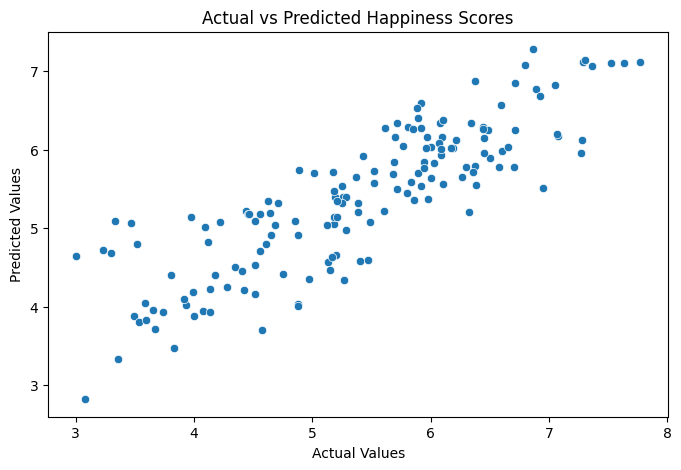

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Actual Happiness Score',
    y='Predicted Happiness Score',
    data=prediction_comparison
)

plt.title("Actual vs Predicted Happiness Scores")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

## Residual Analysis

Residual analysis evaluates the difference between actual and predicted values.

Smaller residuals indicate that the model predictions are closer to the real Happiness Scores.

In [57]:
# Calculate residuals

residuals = (
    prediction_comparison['Actual Happiness Score']
    -
    prediction_comparison['Predicted Happiness Score']
)


# Display residual statistics

residuals.describe()

count    157.000000
mean      -0.000960
std        0.575373
min       -1.760579
25%       -0.285737
50%        0.015700
75%        0.360221
max        1.433958
dtype: float64

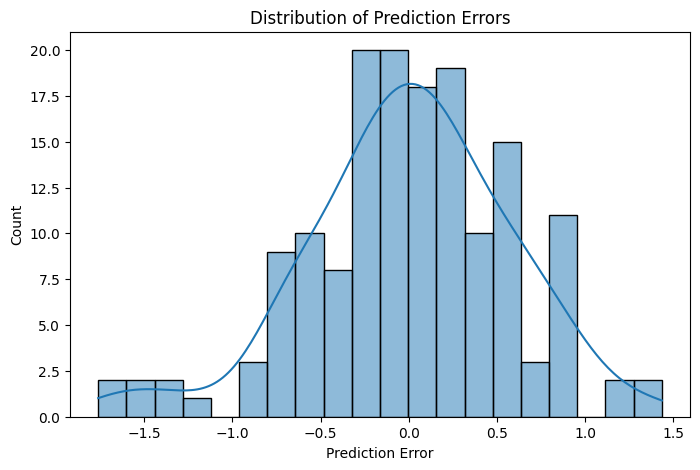

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")

plt.show()

### Residual Interpretation

The residual distribution shows how prediction errors are distributed.

A model with residuals concentrated around zero indicates better predictive performance because predicted values are closer to actual values.

## Feature Importance Analysis

The coefficients from the regression model are analyzed to understand which factors contribute most strongly to happiness prediction.

In [59]:
# Analyze Ridge Regression coefficients

feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_ridge_model.coef_
})


feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
3,Freedom,1.461668
4,Trust,1.190391
0,GDP,1.062513
2,Health,1.035400
1,Social Support,0.664122
5,Generosity,0.470857


### Feature Importance Interpretation

The coefficient analysis indicates which socioeconomic factors have the strongest influence on predicted Happiness Scores.

Positive coefficients suggest that increases in those variables contribute to higher predicted happiness levels.

# Final Conclusion

This project analyzed World Happiness Report data from 2015 to 2019 to understand the main drivers of happiness across countries.

Exploratory Data Analysis revealed important relationships between Happiness Score and socioeconomic indicators.

Key findings include:

- GDP per capita showed a strong positive relationship with happiness.
- Social Support and Health indicators were among the most influential predictors.
- Countries with stronger economic conditions and better quality-of-life indicators generally reported higher happiness scores.
- Multiple-variable machine learning models performed better than single-variable models because happiness depends on several factors.

Three regression techniques were developed and compared:

- Linear Regression
- Polynomial Regression
- Ridge Regression

Model performance was evaluated using:

- RMSE
- MAE
- R² Score

Ridge Regression with GridSearchCV provided a regularized approach by selecting the best alpha parameter and reducing the risk of overfitting.

Overall, this project demonstrates how machine learning can be used to analyze global socioeconomic data and predict happiness levels using measurable indicators.